In [ ]:
import os
import re
from collections import defaultdict
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

def get_dirs(pattern, root_dir='../runs'):
    matching_dirs = []

    for dirpath, _, _ in os.walk(root_dir):
        rel_path = os.path.relpath(dirpath, root_dir)
        if pattern.search(rel_path):
            matching_dirs.append(os.path.join(root_dir, rel_path))

    print("Matched directories:")
    for path in matching_dirs:
        print(path)
    
    return matching_dirs

def _find_event_file(log_dir: str) -> str:
    """
    Given a directory `log_dir` (which should contain one or more
    'events.out.tfevents.*' files), return the first matching filename.
    Raises FileNotFoundError if no event file is found.
    """
    for fname in os.listdir(log_dir):
        if "events.out.tfevents" in fname:
            return os.path.join(log_dir, fname)
    raise FileNotFoundError(f"No TensorBoard event file found in {log_dir!r}.")

def extract_scalars_from_event(event_file: str, tag: str):
    """
    Read one TensorBoard event file and pull out all (step, value, wall_time) triples
    for the scalar `tag`. Returns three parallel lists: (steps, values, wall_times).

    Raises:
        ValueError if `tag` is not present in that event file.
    """
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={"scalars": 0}  # 0 → load all scalar events
    )
    ea.Reload()

    available_tags = ea.Tags().get("scalars", [])
    if tag not in available_tags:
        raise ValueError(
            f"Tag {tag!r} not found in {os.path.basename(event_file)}. "
            f"Available scalar tags are: {available_tags}"
        )

    events = ea.Scalars(tag)
    steps      = [e.step      for e in events]
    values     = [e.value     for e in events]
    wall_times = [e.wall_time for e in events]
    return steps, values, wall_times

def _parse_seed_from_dir(dirpath: str) -> int:
    """
    Given a path that ends in '_s<digit>' (e.g. '..._s2/tensorboard_logs'),
    return the integer seed. Raises ValueError if no '_sN' is found.
    """
    m = re.search(r"_s([0-9]+)(?:/|$)", dirpath)
    if not m:
        raise ValueError(f"Cannot find a seed in directory name: {dirpath!r}")
    return int(m.group(1))

def _collect_scalar_over_seeds(matching_dirs, tag):
    """
    For each directory in matching_dirs, locate the TensorBoard event file,
    extract (steps, values) for `tag`, and store them in a dict keyed by seed.
    Verifies all seeds share the same 'steps' array; if not, raises an error.

    Returns:
        data_dict: Dict[int → (np.ndarray steps, np.ndarray values)]
    """
    data_dict = {}
    common_steps = None

    for run_dir in matching_dirs:
        seed = _parse_seed_from_dir(run_dir)

        event_path = _find_event_file(run_dir)   # find 'events.out.tfevents.*' in run_dir
        steps, values, _ = extract_scalars_from_event(event_path, tag)

        steps_arr  = np.array(steps, dtype=int)
        values_arr = np.array(values, dtype=float)

        if common_steps is None:
            common_steps = steps_arr
        else:
            # enforce that steps match exactly
            if not np.array_equal(common_steps, steps_arr):
                raise RuntimeError(
                    f"Step arrays do not match for seed {seed}. "
                    f"Got shape {steps_arr.shape}, expected {common_steps.shape}."
                )

        data_dict[seed] = (steps_arr, values_arr)

    return data_dict

def compute_mean_std(data_dict):
    """
    Given data_dict: {seed → (steps, values_array)}, extract all values
    into one 2D array of shape (num_seeds, num_steps) and compute
    mean and std along axis=0.

    Returns:
        mean_values: np.ndarray of shape (num_steps,)
        std_values:  np.ndarray of shape (num_steps,)
    """
    # Sort by seed key to keep ordering consistent
    seeds = sorted(data_dict.keys())
    values_list = [data_dict[s][1] for s in seeds]  # list of 1D arrays

    stacked = np.stack(values_list, axis=0)  # shape = (num_seeds, num_steps)
    mean_vals = np.mean(stacked, axis=0)
    std_vals  = np.std (stacked, axis=0)

    return mean_vals, std_vals

def get_loss_stats(matching_dirs):
    """
    High-level function to get:
      steps, train_mean, train_std, val_mean, val_std

    1) Collect “Loss/Train” over all seeds
    2) Collect “Loss/Validation” over all seeds
    3) Guarantee steps match
    4) Return steps + (mean/std) for both tags.

    Returns:
        steps:       np.ndarray of shape (num_steps,)
        train_mean:  np.ndarray of shape (num_steps,)
        train_std:   np.ndarray of shape (num_steps,)
        val_mean:    np.ndarray of shape (num_steps,)
        val_std:     np.ndarray of shape (num_steps,)
    """
    # 1) Collect all seeds for "Loss/Train"
    train_dict = _collect_scalar_over_seeds(matching_dirs, "Loss/Train")
    # 2) Collect all seeds for "Loss/Validation"
    val_dict   = _collect_scalar_over_seeds(matching_dirs, "Loss/Validation")

    # Both dicts have the same keys and same step arrays (validated inside _collect_…)
    # Extract any seed’s steps to use as the common axis.
    any_seed = next(iter(train_dict))
    steps = train_dict[any_seed][0]  # np.ndarray of ints

    # 3) Compute mean and std
    train_mean, train_std = compute_mean_std({s: train_dict[s] for s in train_dict})
    val_mean,   val_std   = compute_mean_std({s: val_dict[s]   for s in val_dict})

    return steps, train_mean, train_std, val_mean, val_std

def group_curvature_tags(all_scalar_tags):
    """
    Given a list of scalar tags (strings), return a mapping:
      layer_index (int) → [list of full tag strings for that layer, sorted by head index].
    Only tags that match the pattern "Curvature/layer_<i>/head_<j>" are included.

    e.g. input: ["Curvature/layer_0/head_0", "Curvature/layer_0/head_1",
                 "Curvature/layer_1/head_0", ...]
         output: { 0: ["Curvature/layer_0/head_0",
                       "Curvature/layer_0/head_1", …],
                   1: ["Curvature/layer_1/head_0", …], … }
    """
    regex = re.compile(r"^Curvature/layer_([0-9]+)/(head_[0-9]+)$")
    layer_dict = defaultdict(list)

    for tag in all_scalar_tags:
        m = regex.match(tag)
        if m:
            layer_idx = int(m.group(1))
            head_part = m.group(2)  # e.g. "head_0"
            layer_dict[layer_idx].append( (int(head_part.split('_')[1]), tag) )
            # we store (head_index, full_tag) so we can sort by head index

    # Sort by head index inside each layer, then discard the head index
    grouped = {}
    for layer_idx, head_list in layer_dict.items():
        head_list.sort(key=lambda x: x[0])  # sort by head index
        grouped[layer_idx] = [ full_tag for (_h, full_tag) in head_list ]

    return grouped  # Dict[int, List[str]]

def extract_curvature_by_run(run_dir, grouped_tags):
    """
    For one run directory (e.g. '../runs/.../some_s0/tensorboard_logs/'),
    returns a nested dict:

      curvature_data[layer_idx][head_idx] = (steps_array, values_array)

    - `grouped_tags` is the output of group_curvature_tags(all_scalar_tags_for_that_run).
    - We assume each run_dir has exactly one event file → _find_event_file(run_dir).
    - We extract step/value for each 'Curvature/layer_i/head_j' tag.

    Example return structure:
      {
        0: { 0: (steps, values_for_layer0_head0),
             1: (steps, values_for_layer0_head1),
             … },
        1: { 0: (steps, values_for_layer1_head0), … },
        … 
      }
    """
    event_path = _find_event_file(run_dir)
    curvature_data = {}

    for layer_idx, tag_list in grouped_tags.items():
        # For each layer, we'll create an inner dict mapping head_idx → (steps, values)
        curvature_data[layer_idx] = {}
        for full_tag in tag_list:
            # Parse out head index from tag, e.g. "Curvature/layer_3/head_5" → head_idx=5
            h = int(full_tag.split('/')[-1].split('_')[1])

            steps, values, _ = extract_scalars_from_event(event_path, full_tag)
            curvature_data[layer_idx][h] = (np.array(steps, dtype=int),
                                            np.array(values, dtype=float))

    return curvature_data


In [ ]:
pattern = re.compile(f"sh_.+_402K.*/tensorboard_logs")
dirs = get_dirs(pattern)

In [14]:
keys = ['sh_ee', 'sh_eh_lr1', 'sh_eh_lr3', 'sh_eh_lr10', 'sh_eh_lr33']
losses = {}
for k in keys:
    pattern = re.compile(f"{k}_402K.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)
    loss_stats = get_loss_stats(matching_dirs)
    losses[k] = loss_stats

Matched directories:
../runs/05.31/68072_sh_ee_402K_s0/tensorboard_logs
../runs/05.31/68527_sh_ee_402K_s1/tensorboard_logs
../runs/05.31/68696_sh_ee_402K_s2/tensorboard_logs
../runs/05.31/68877_sh_ee_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/69397_sh_eh_lr1_402K_s0/tensorboard_logs
../runs/05.31/69665_sh_eh_lr1_402K_s1/tensorboard_logs
../runs/05.31/69908_sh_eh_lr1_402K_s2/tensorboard_logs
../runs/05.31/70154_sh_eh_lr1_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/70395_sh_eh_lr3_402K_s0/tensorboard_logs
../runs/05.31/70637_sh_eh_lr3_402K_s1/tensorboard_logs
../runs/05.31/70883_sh_eh_lr3_402K_s2/tensorboard_logs
../runs/05.31/71123_sh_eh_lr3_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/71365_sh_eh_lr10_402K_s0/tensorboard_logs
../runs/05.31/71610_sh_eh_lr10_402K_s1/tensorboard_logs
../runs/05.31/71850_sh_eh_lr10_402K_s2/tensorboard_logs
../runs/05.31/72091_sh_eh_lr10_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/72337_sh_eh_l

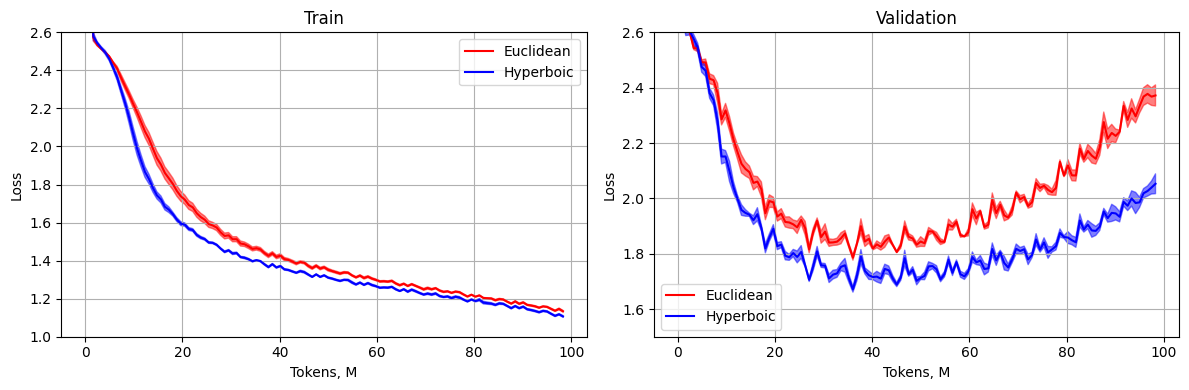

In [ ]:
def plot_losses(ax, loss_stats, label, color='crimson'):
    ax1, ax2 = ax
    steps_, train_mean, train_std, val_mean, val_std = loss_stats
    steps = steps_ / 1e6
    ax1.plot(steps, train_mean,   label=label, color=color)
    ax1.fill_between(steps,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.5, color=color)
    ax1.set_title('Train')
    ax2.plot(steps, val_mean,     label=label,   color=color)
    ax2.fill_between(steps,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.5, color=color)
    ax2.set_title('Validation')
    
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_losses(axs, losses['sh_ee'], 'Euclidean', 'red')
plot_losses(axs, losses['sh_eh_lr1'], 'Hyperbolic', 'blue')

for ax in axs:
    ax.set_xlabel("Tokens, M")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

axs[0].set_ylim([1., 2.6])
axs[1].set_ylim([1.5, 2.6])

plt.tight_layout()
plt.show()


In [23]:
def get_curvatures(dir):
    event = _find_event_file(dir)
    ea = event_accumulator.EventAccumulator(event, size_guidance={'scalars': 0})
    ea.Reload()
    all_tags = ea.Tags().get("scalars", [])
    grouped_tags = group_curvature_tags(all_tags)
    run_curvatures = extract_curvature_by_run(matching_dirs[0], grouped_tags)
    return run_curvatures # nested dict: run0_curvature[layer_idx][head_idx] = (steps, values)

keys = ['sh_eh_lr1', 'sh_eh_lr3', 'sh_eh_lr10', 'sh_eh_lr33']
curvature_dict = {}

for k in keys:
    pattern = re.compile(f"{k}_402K.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)
    curv_ = {}
    for dir in matching_dirs:
        s = _parse_seed_from_dir(dir)
        curv_[s] = get_curvatures(dir)
    curvature_dict[k] = curv_

Matched directories:
../runs/05.31/69397_sh_eh_lr1_402K_s0/tensorboard_logs
../runs/05.31/69665_sh_eh_lr1_402K_s1/tensorboard_logs
../runs/05.31/69908_sh_eh_lr1_402K_s2/tensorboard_logs
../runs/05.31/70154_sh_eh_lr1_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/70395_sh_eh_lr3_402K_s0/tensorboard_logs
../runs/05.31/70637_sh_eh_lr3_402K_s1/tensorboard_logs
../runs/05.31/70883_sh_eh_lr3_402K_s2/tensorboard_logs
../runs/05.31/71123_sh_eh_lr3_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/71365_sh_eh_lr10_402K_s0/tensorboard_logs
../runs/05.31/71610_sh_eh_lr10_402K_s1/tensorboard_logs
../runs/05.31/71850_sh_eh_lr10_402K_s2/tensorboard_logs
../runs/05.31/72091_sh_eh_lr10_402K_s3/tensorboard_logs
Matched directories:
../runs/05.31/72337_sh_eh_lr33_402K_s0/tensorboard_logs
../runs/05.31/72580_sh_eh_lr33_402K_s1/tensorboard_logs
../runs/05.31/72830_sh_eh_lr33_402K_s2/tensorboard_logs
../runs/05.31/73072_sh_eh_lr33_402K_s3/tensorboard_logs


In [24]:
import pickle

with open('shakespeare_curvatures.pkl', 'wb') as f:
    pickle.dump(curvature_dict, f)

# with open('data.pkl', 'rb') as f:
#     loaded_dict = pickle.load(f)


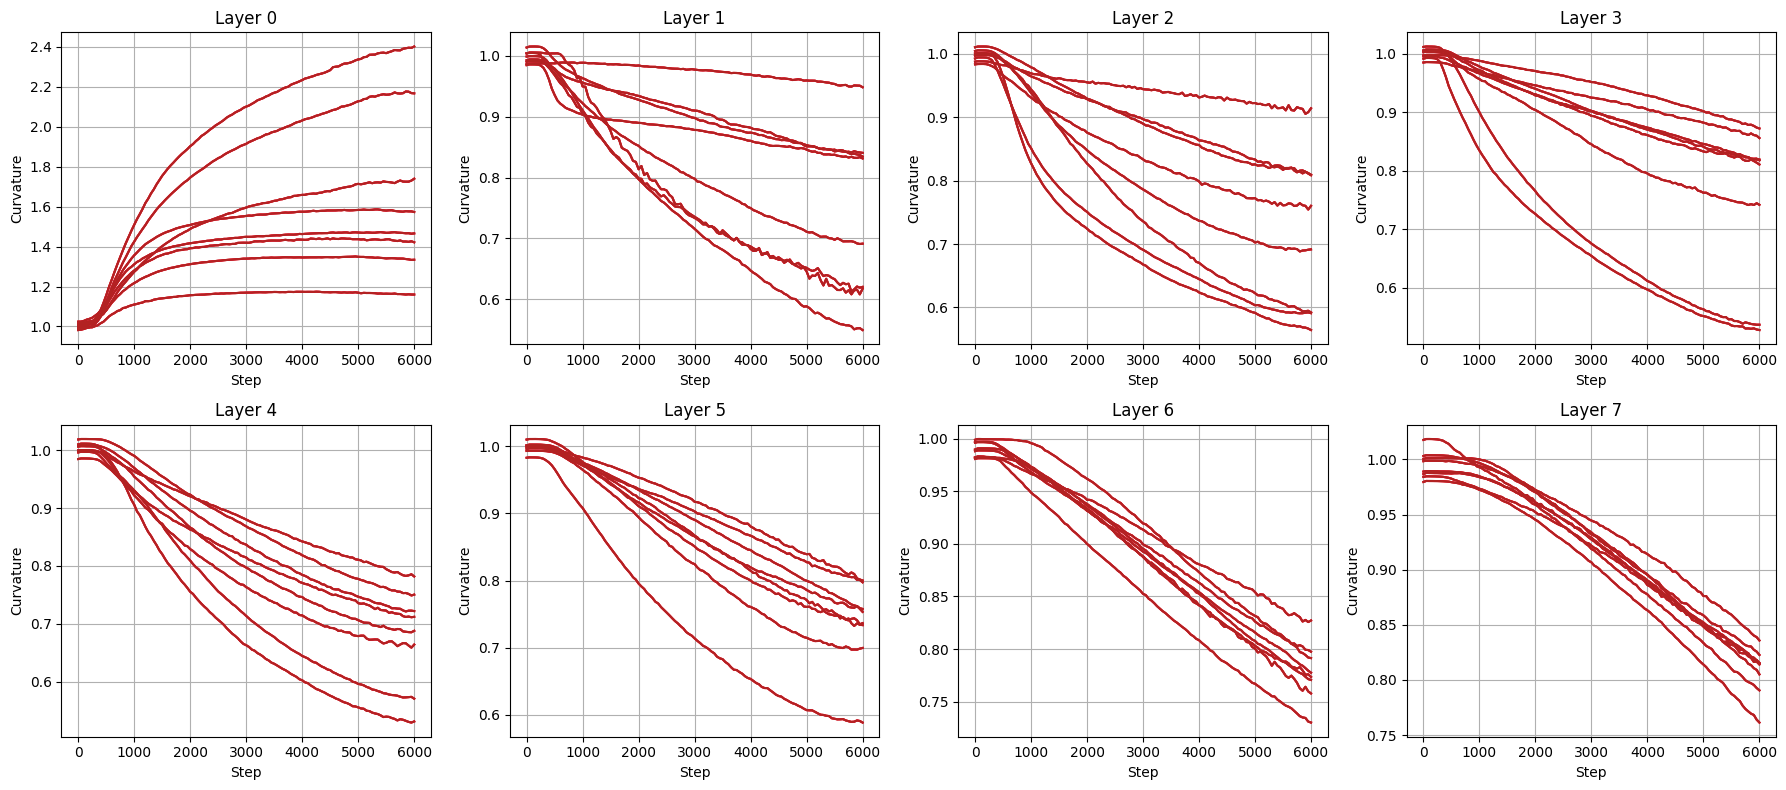

In [38]:
def plot_layer_curvatures(ax, curv, color='red', title=None):
    for head_idx, (steps_i, values_i) in curv.items():
        ax.plot(steps_i, values_i, color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel("Curvature")
    if title is not None:
        ax.set_title(title)
    # ax.set_yscale('log')
    # ax.legend(loc="upper right", fontsize="small")
    ax.grid(True)

curv = curvature_dict['sh_eh_lr1']

fig, axs = plt.subplots(2, 4, figsize=(18, 8))

for s, c in enumerate(['red', 'crimson', 'firebrick']):
    for layer, ax in enumerate(axs.flatten()):
        plot_layer_curvatures(ax, curv[s][layer], title=f"Layer {layer}", color=c)

plt.tight_layout()
plt.show()

In [ ]:
# 2e) If you also want seed-averaged curvature for, say, layer=3, head=2:
all_vals = []
common_steps = None

for rd in matching_dirs:
    run_curv = extract_curvature_by_run(rd, grouped_tags)
    steps_i, values_i = run_curv[3][2]  # layer=3, head=2
    if common_steps is None:
        common_steps = steps_i
    else:
        if not np.array_equal(common_steps, steps_i):
            raise RuntimeError("Step-mismatch for layer=3, head=2 across seeds.")
    all_vals.append(values_i)

stacked = np.stack(all_vals, axis=0)  # shape = (num_seeds, num_steps)
mean_vals = np.mean(stacked, axis=0)
std_vals  = np.std (stacked, axis=0)

plt.figure(figsize=(6,4))
plt.plot(common_steps, mean_vals, label="mean (layer=3, head=2)")
plt.fill_between(common_steps,
                 mean_vals - std_vals,
                 mean_vals + std_vals,
                 alpha=0.3)
plt.xlabel("Step")
plt.ylabel("Curvature")
plt.title("Layer 3, Head 2: mean ± std over seeds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def group_by_k_and_hyp(paths):
    groups_ts = defaultdict(list)  # Group for `hyp` numbers
    groups_fw = defaultdict(list)  # Group for `k` numbers and `euc`
    
    # Define the regex patterns
    k_pattern = re.compile(r'k_([\d.]+)')  # Matches numbers after `k_`
    hyp_pattern = re.compile(r'hyp_([\d.]+)')  # Matches numbers after `hyp_`
    
    for path in paths:
        # Check for `euc` in the path name
        if 'euc' in path:
            groups_fw['euc'].append(path)
            continue
        
        # Check for `k` and extract the number
        k_match = k_pattern.search(path)
        if k_match:
            key = f'{k_match.group(1)}'
            groups_fw[key].append(path)
            continue
        
        # Check for `hyp` and extract the number
        hyp_match = hyp_pattern.search(path)
        if hyp_match:
            key = f'{hyp_match.group(1)}'
            groups_ts[key].append(path)
    
    return dict(groups_ts), dict(groups_fw)

result1, result2 = group_by_k_and_hyp(logdirs)
result1.keys(), result2.keys()

In [ ]:
import os
from tensorboard.backend.event_processing import event_accumulator

def load_tensorboard_logs(groups):
    def extract_scalars(log_path, tag):
        # Load TensorBoard logs
        if not os.path.exists(log_path):
            print(f"Path does not exist: {log_path}")
            return []
        try:
            ea = event_accumulator.EventAccumulator(log_path)
            ea.Reload()
            if tag in ea.Tags().get('scalars', []):
                scalars = ea.Scalars(tag)
                return [(event.step, event.value)for event in scalars]
            else:
                print(f"Tag '{tag}' not found in {log_path}")
                return []
        except Exception as e:
            print(f"Failed to load {log_path}: {e}")
            return []
    
    results = {}
    for group, paths in groups.items():
        train = []
        val = []
        train_lengths = []
        val_lengths = []
        for path in paths:
            train_losses = extract_scalars(path, 'Loss/Train')
            val_losses = extract_scalars(path, 'Loss/Validation')
            train.append(train_losses)
            val.append(val_losses)
            train_lengths.append(len(train_losses))
            val_lengths.append(len(val_losses))
        
        print(f"Group '{group}':")
        print(f"  Train lengths: {train_lengths}")
        print(f"  Validation lengths: {val_lengths}")
        results[group] = {"Train": train, "Validation": val}
    
    return results

res_plots = load_tensorboard_logs(result2)

In [ ]:
for split, plots in res_plots['1.0'].items():
    for p in plots:
        ar = [v for _, v in p[490:]]
        print(np.mean(ar))

In [ ]:
import os
import numpy as np
from tensorboard.backend.event_processing import event_accumulator

def load_tensorboard_logs_th(groups, threshold=None):
    def extract_scalars(log_path, tag):
        # Load TensorBoard logs
        if not os.path.exists(log_path):
            print(f"Path does not exist: {log_path}")
            return []
        try:
            ea = event_accumulator.EventAccumulator(log_path)
            ea.Reload()
            if tag in ea.Tags().get('scalars', []):
                scalars = ea.Scalars(tag)
                return [(event.step, event.value) for event in scalars]
            else:
                print(f"Tag '{tag}' not found in {log_path}")
                return []
        except Exception as e:
            print(f"Failed to load {log_path}: {e}")
            return []
    
    results = {}
    for group, paths in groups.items():
        train = []
        val = []
        train_lengths = []
        val_lengths = []
        for path in paths:
            train_losses = extract_scalars(path, 'Loss/Train')
            val_losses = extract_scalars(path, 'Loss/Validation')

            # Apply threshold filtering if specified
            if threshold is not None:
                if len(train_losses) > 490:
                    train_ar = [v for _, v in train_losses[490:]]
                    train_mean = np.mean(train_ar)
                else:
                    train_mean = float('inf')

                if len(val_losses) > 490:
                    val_ar = [v for _, v in val_losses[490:]]
                    val_mean = np.mean(val_ar)
                else:
                    val_mean = float('inf')

                print(f"Path: {path}")
                print(f"  Train Mean (steps 490+): {train_mean}")
                print(f"  Validation Mean (steps 490+): {val_mean}")

                # Keep only plots where the mean <= threshold
                if train_mean <= threshold:
                    train.append(train_losses)
                else:
                    print(f"  Excluding Train plot due to high mean.")

                if val_mean <= threshold:
                    val.append(val_losses)
                else:
                    print(f"  Excluding Validation plot due to high mean.")
            else:
                train.append(train_losses)
                val.append(val_losses)
            
            train_lengths.append(len(train_losses))
            val_lengths.append(len(val_losses))
        
        print(f"Group '{group}':")
        print(f"  Train lengths: {train_lengths}")
        print(f"  Validation lengths: {val_lengths}")
        results[group] = {"Train": train, "Validation": val}
    
    return results

# Usage Example
threshold = 5.0
res_plots = load_tensorboard_logs_th(result2, threshold=threshold)

In [ ]:
import matplotlib.pyplot as plt

def plot_all_curves(results):
    for group, data in results.items():
        # Create a figure with two subplots (Train and Validation)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        fig.suptitle(f'Group: {group}')
        
        # --- Plot Train curves ---
        for run in data["Train"]:
            steps = [step for step, val in run]
            values = [val for step, val in run]
            axes[0].plot(steps, values, marker='o', label=f'Run {data["Train"].index(run)+1}')
        axes[0].set_title("Train")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Value")
        axes[0].legend(loc='best', fontsize='small')
        axes[0].grid()

        # --- Plot Validation curves ---
        for run in data["Validation"]:
            steps = [step for step, val in run]
            values = [val for step, val in run]
            axes[1].plot(steps, values, marker='o', label=f'Run {data["Validation"].index(run)+1}')
        axes[1].set_title("Validation")
        axes[1].set_xlabel("Step")
        axes[1].legend(loc='best', fontsize='small')
        axes[1].grid()
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.85)  # Adjust for suptitle
        plt.show()

# Example usage:
plot_all_curves(res_plots)

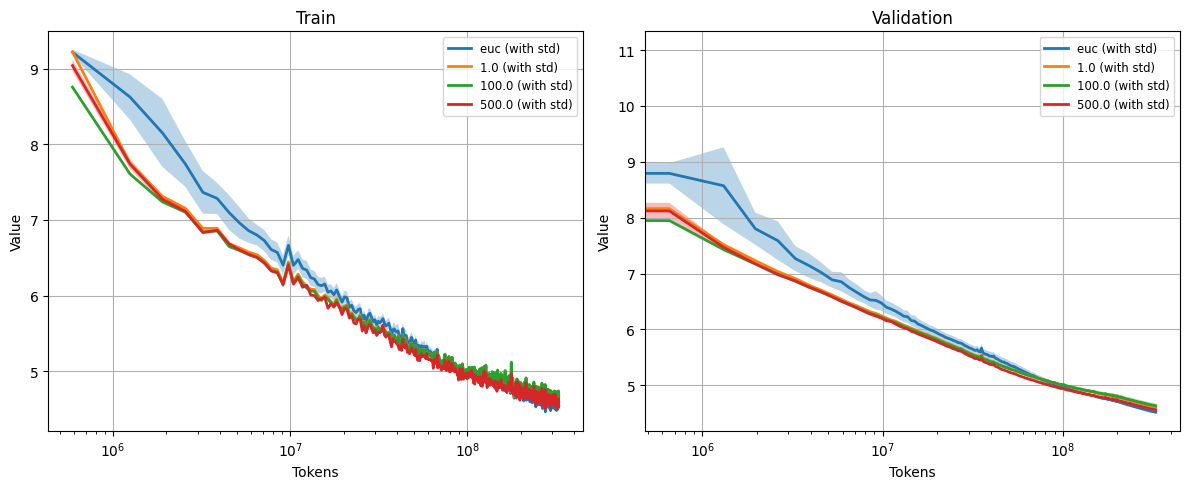

In [65]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val(
    results,
    alpha_fill=0.2,
    x_range=None,
    y_range=None
):
    """
    Plots Train (all groups on one figure) and Validation (all groups on another),
    showing only mean ± std (no individual runs).
    
    Parameters
    ----------
    results : dict
        A dictionary of the form:
            {
              group_name : {
                "Train": [ [(step, val), ...], [(step, val), ...], ... ],
                "Validation": [ [(step, val), ...], [(step, val), ...], ... ]
              },
              ...
            }
    alpha_fill : float, optional
        Transparency for the fill_between shading, by default 0.2
    x_range : tuple or list, optional
        (xmin, xmax) to set the X-axis range, by default None
    y_range : tuple or list, optional
        (ymin, ymax) to set the Y-axis range, by default None
    """
    # --- Create two separate figures: one for Train, one for Validation ---
    fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(12, 5))
    
    for group, data in results.items():
        # --- TRAIN ---
        train_runs = data.get("Train", [])
        if train_runs:
            # Compute mean and std across runs (assuming same steps in each run)
            vals_array = np.array([[val for (_, val) in run] for run in train_runs])
            steps = [step for (step, _) in train_runs[0]]
            mean_vals = vals_array.mean(axis=0)
            std_vals = vals_array.std(axis=0)
            
            # Plot fill + mean
            ax_train.fill_between(steps,
                                  mean_vals - std_vals,
                                  mean_vals + std_vals,
                                  alpha=alpha_fill)
            ax_train.plot(steps, mean_vals, label=f"{group} (with std)", linewidth=2)
        
        # --- VALIDATION ---
        val_runs = data.get("Validation", [])
        if val_runs:
            # Compute mean and std across runs (assuming same steps in each run)
            vals_array = np.array([[val for (_, val) in run] for run in val_runs])
            steps = [step for (step, _) in val_runs[0]]
            mean_vals = vals_array.mean(axis=0)
            std_vals = vals_array.std(axis=0)
            
            # Plot fill + mean
            ax_val.fill_between(steps,
                                mean_vals - std_vals,
                                mean_vals + std_vals,
                                alpha=alpha_fill)
            ax_val.plot(steps, mean_vals, label=f"{group} (with std)", linewidth=2)
    
    # --- Configure axes ---
    # Rename X-axis to "Tokens"
    ax_train.set_xlabel("Tokens")
    ax_train.set_ylabel("Value")
    ax_train.set_title("Train")
    ax_train.grid()
    ax_train.legend(loc='best', fontsize='small')
    
    ax_val.set_xlabel("Tokens")
    ax_val.set_ylabel("Value")
    ax_val.set_title("Validation")
    ax_val.grid()
    ax_val.legend(loc='best', fontsize='small')
    
    # --- Apply range limits if provided ---
    if x_range is not None:
        ax_train.set_xlim(x_range)
        ax_val.set_xlim(x_range)
    if y_range is not None:
        ax_train.set_ylim(y_range)
        ax_val.set_ylim(y_range)

    ax_val.set_xscale('log')
    ax_train.set_xscale('log')
    
    plt.tight_layout()
    plt.show()

plot_train_val(
    results=res_plots,
    alpha_fill=0.3
    # x_range=(1e8, 3e8)
    # y_range=(0, 1.0)
)
